<a href="https://colab.research.google.com/github/DiasFrazerGroup/Intro-to-probabilistic-modelling-2026/blob/main/Session3b_CompressedSensing_WithAnswers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compressed Sensing: Pooled Experimental Design for T-Cell Epitope Discovery
*Session 3b — An Introduction to Probabilistic Model Building*

---

The central idea: **sparsity isn't just a regularisation trick — it enables a fundamentally different experimental strategy.**  
When you know your signal is sparse, you don't have to measure every element individually.  
You can design $M \ll N$ pooled measurements and still recover the $K$ active elements, provided the pooling matrix is designed correctly.

---

## The experimental scenario

You have a library of **96 synthetic peptides** spanning the spike protein of a novel pathogen.  
You want to find the ~5 that trigger a T-cell response (T-cell *epitopes*) using an **ELISPOT assay**.

**Standard approach:** test each peptide individually — 96 wells, expensive and slow.  
**Compressed sensing approach:** pool peptides into 30 cleverly designed mixtures, test the pools, deconvolve to identify the active epitopes.

The key question: *how should you design those 30 pools?*

In [ ]:
!pip install pymc arviz scikit-learn matplotlib numpy --quiet

In [ ]:
import logging
logging.getLogger('pymc').setLevel(logging.ERROR)
logging.getLogger('pytensor').setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pymc as pm
import arviz as az
from sklearn.linear_model import LassoCV

print("PyMC:", pm.__version__)
print("ArviZ:", az.__version__)

PyMC: 5.28.4
ArviZ: 0.22.0


## §1  Setting up the experiment

### The ELISPOT assay

ELISPOT (Enzyme-Linked ImmunoSpot) measures how many T cells in a blood sample respond to a stimulus.  
Each well contains ~250,000 peripheral blood mononuclear cells (PBMCs) and one or more peptides.  
If a T cell recognises a peptide (via its T-cell receptor binding to MHC-peptide complexes),  
it secretes IFN-γ, leaving a visible "spot."  The readout is **spot count per 10⁶ PBMCs**.

For a non-responder peptide: background noise, ~0–45 spots (3σ ≈ 45 with σ = 15).  
For a true T-cell epitope: 60–200 spots above background.

### The additivity assumption

When a pool contains multiple peptides, the total response is approximately the **sum of individual responses** — T cells react independently to each peptide they recognise.  This additivity is what makes the linear model $y = Ax + \varepsilon$ valid.

### The measurement model

$$y_j = \sum_{i=1}^{N} A_{ji}\, x_i + \varepsilon_j, \qquad \varepsilon_j \sim \mathcal{N}(0, \sigma^2)$$

| Symbol | Meaning |
|--------|---------|
| $N = 96$ | Total candidate peptides |
| $K = 5$ | True T-cell epitopes (unknown to us — what we're trying to find) |
| $x_i$ | True ELISPOT response of peptide $i$ alone (latent — never directly observed) |
| $A_{ji}$ | 1 if peptide $i$ is in pool $j$, else 0 — your **experimental design choice** |
| $y_j$ | Measured response of pool $j$ (observed) |
| $M$ | Number of pools — a free parameter you choose |

In [ ]:
rng = np.random.default_rng(42)

# ── Experimental parameters ───────────────────────────────────────────────────
N       = 96      # candidate peptides (one 96-well plate of individual peptides)
K       = 5       # true T-cell epitopes — sparse!
n_rows  = 8       # rows in the plate layout (for the grid design)
n_cols  = 12      # columns in the plate layout
sigma   = 15.0    # ELISPOT background noise (spot counts / 10^6 PBMCs)

# ── Ground truth: which peptides are epitopes and how strong are they? ────────
# In a real experiment we don't know this — it's what we're trying to discover.
# Here we generate it synthetically so we can evaluate our designs.
active_idx = rng.choice(N, K, replace=False)   # randomly pick 5 epitopes
x_true     = np.zeros(N)
x_true[active_idx] = rng.uniform(60, 200, K)  # realistic ELISPOT spot counts

# ── Print the ground truth ────────────────────────────────────────────────────
print(f"True epitopes (this is what we're trying to discover):")
print(f"  {'Peptide':>8}  {'Row':>4}  {'Col':>4}  {'True response':>14}")
print(f"  {'(index)':>8}  {'(1-8)':>4}  {'(1-12)':>4}  {'(spots/10^6)':>14}")
print("  " + "-" * 38)
for idx in sorted(active_idx):
    r, c = divmod(idx, n_cols)
    print(f"  P{idx+1:>7d}  {r+1:>4d}  {c+1:>4d}  {x_true[idx]:>14.1f}")
print()
print(f"Standard approach: test all {N} peptides individually = {N} ELISPOT wells")
print(f"Each well costs ~€50; full screen = €{N*50:,}")
print(f"Goal: identify the same {K} epitopes using far fewer wells")

True epitopes (this is what we're trying to discover):
   Peptide   Row   Col   True response
   (index)  (1-8)  (1-12)    (spots/10^6)
  --------------------------------------
  P      9     1     9            77.9
  P     42     4     6           166.6
  P     62     6     2           170.0
  P     72     6    12           196.6
  P     96     8    12           123.1

Standard approach: test all 96 peptides individually = 96 ELISPOT wells
Each well costs ~€50; full screen = €4,800
Goal: identify the same 5 epitopes using far fewer wells


## §2  The pooling design

**Why not test each peptide individually?**  
With 96 peptides at ~€50 per ELISPOT well, a full individual screen costs €4,800 and consumes
a large volume of precious patient blood.  We want to identify the same 5 epitopes using far fewer wells.

**The key insight: random pooling.**  
Each peptide is independently assigned to each pool with probability $p = 0.3$.  
This gives every peptide a unique random binary "fingerprint" — its pattern of pool memberships.  
Two peptides accidentally sharing the same fingerprint across 30 pools is astronomically unlikely.

**Why random rather than structured?**  
Structured designs — such as assigning peptides by row and column on the 96-well plate —
create systematic ambiguities: two epitopes in the same row share all their row-pool signals,
making them impossible to disentangle without additional experiments.
Random designs avoid all such shared structure by construction.

**Theoretical guarantee (Restricted Isometry Property):**  
A random $M \times N$ binary matrix will allow exact recovery of any $K$-sparse signal with high
probability when the number of pools satisfies:

$$M \geq 2K \log\!\left(\frac{N}{K}\right)$$

With $K = 5$, $N = 96$: $M^* \approx 2 \times 5 \times \log(19.2) \approx 29$.  
We use $M = 30$ pools — just above the theoretical threshold.

CS design matrix properties:
  Shape: (30, 96)  (30 pools × 96 peptides)
  Average peptides per pool: 29.1
  Average pools per peptide: 9.1
  Theoretical threshold M* = 2K·log(N/K) = 30
  Our design uses M = 30 pools (just above threshold)


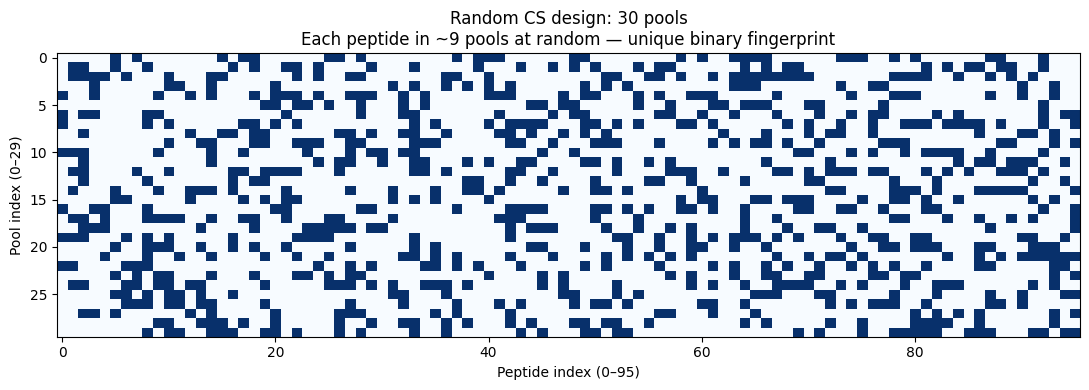


Observed pool responses: range [-25, 579] spot counts
Pools containing epitopes read higher; background noise SD = 15 spots


In [ ]:
# ── Random CS design ──────────────────────────────────────────────────────────
# Each entry A_cs[j,i] = 1 independently with probability p = 0.3.
# This gives every peptide a unique random binary "fingerprint" across all pools.
# No structured rows or columns — every peptide looks distinct to the recovery algorithm.
M_cs = 30
p_include = 0.3
A_cs = (rng.random((M_cs, N)) < p_include).astype(float)

# ── Verify design properties ──────────────────────────────────────────────────
theoretical_M = 2 * K * np.log(N / K)
print("CS design matrix properties:")
print(f"  Shape: {A_cs.shape}  ({M_cs} pools × {N} peptides)")
print(f"  Average peptides per pool: {A_cs.sum(axis=1).mean():.1f}")
print(f"  Average pools per peptide: {A_cs.sum(axis=0).mean():.1f}")
print(f"  Theoretical threshold M* = 2K·log(N/K) = {theoretical_M:.0f}")
print(f"  Our design uses M = {M_cs} pools (just above threshold)")

# ── Visualise the design matrix ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.imshow(A_cs, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax.set_xlabel("Peptide index (0–95)")
ax.set_ylabel("Pool index (0–29)")
ax.set_title(
    f"Random CS design: {M_cs} pools\n"
    f"Each peptide in ~{p_include*M_cs:.0f} pools at random — unique binary fingerprint"
)
plt.tight_layout()
plt.show()

# ── Generate noisy pool observations ─────────────────────────────────────────
# Observed response = (design matrix) × (true peptide responses) + Gaussian noise.
# This is the measurement the ELISPOT plate reader would return.
y_cs = A_cs @ x_true + rng.normal(0, sigma, M_cs)
print(f"\nObserved pool responses: range [{y_cs.min():.0f}, {y_cs.max():.0f}] spot counts")
print(f"Pools containing epitopes read higher; background noise SD = {sigma:.0f} spots")

## §3  Lasso recovery: fast and sparse

The random design provides every peptide with a unique binary fingerprint.
Recovery is possible because three conditions hold simultaneously:

1. **The signal is sparse:** only $K = 5$ of 96 peptides are active.
2. **The design satisfies RIP:** a random $M \times N$ binary matrix preserves distances between sparse vectors — random projections don't collapse the sparse signal.
3. **Lasso enforces sparsity:** the $L_1$ penalty drives most coefficients to exactly zero, leaving only the $K$ active ones non-zero.

**Lasso objective:**
$$\hat{x} = \arg\min_{x \geq 0} \frac{1}{2M}\|y - Ax\|_2^2 + \lambda \|x\|_1$$

The regularisation strength $\lambda$ is selected by cross-validation across the $M$ pool measurements.

Lasso recovery (λ = 0.543, selected by 5-fold CV):
  Peptides with non-zero coefficient: 11
  True positives:  5 / 5
  False positives: 6

     Peptide   True response   Lasso estimate    Hit?
  --------------------------------------------------
  P       4             0.0              5.9          detected
  P       9            77.9             67.6  TRUE ✓  detected
  P      38             0.0              5.3          detected
  P      42           166.6            158.9  TRUE ✓  detected
  P      49             0.0              8.4          detected
  P      51             0.0             19.3          detected
  P      57             0.0              6.9          detected
  P      62           170.0            169.8  TRUE ✓  detected
  P      68             0.0              9.0          detected
  P      72           196.6            191.4  TRUE ✓  detected
  P      96           123.1            125.4  TRUE ✓  detected


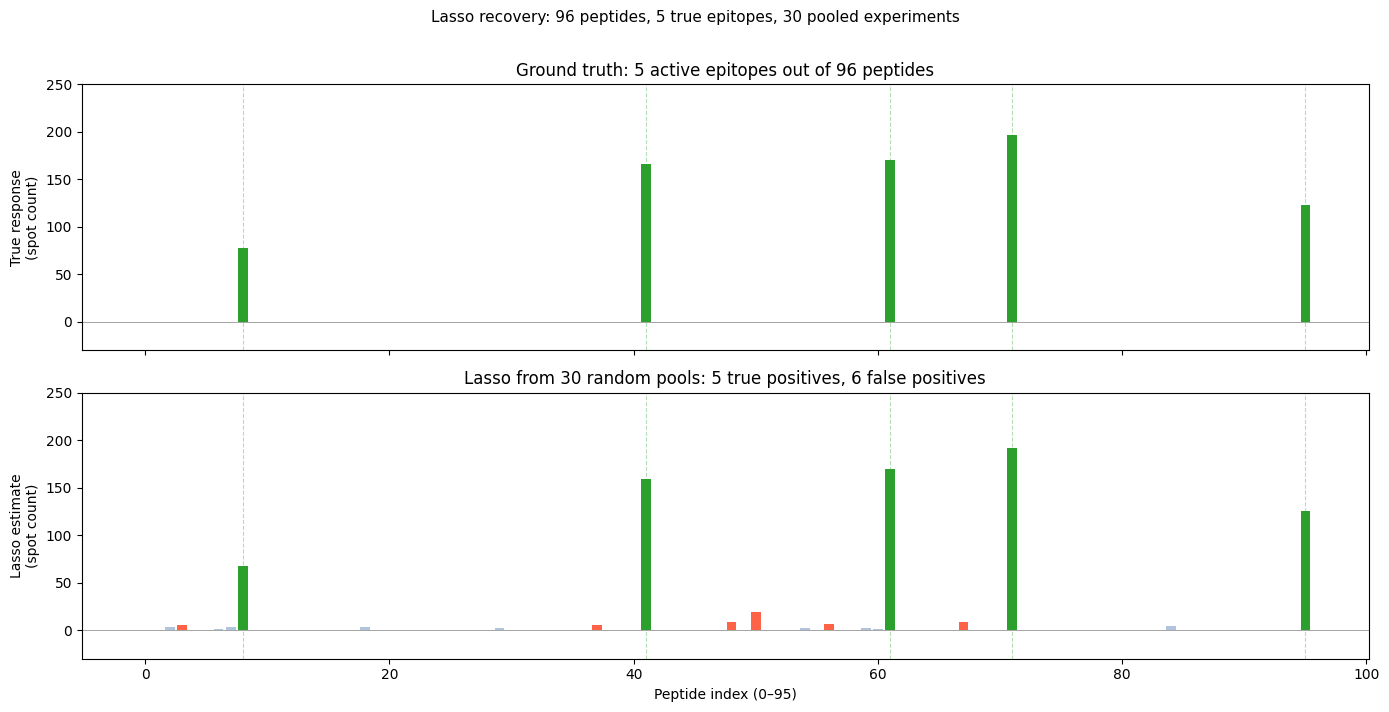

In [ ]:
# ── Lasso recovery from the CS design ────────────────────────────────────────
# LassoCV automatically selects the regularisation strength λ by cross-validation.
lasso = LassoCV(
    cv=5,             # 5-fold cross-validation over the M=30 pool observations
    max_iter=20000,   # enough iterations to converge
    positive=True,    # ELISPOT responses are non-negative — enforce this constraint
    random_state=42
)
lasso.fit(A_cs, y_cs)   # find x such that A_cs @ x ≈ y_cs with L1 sparsity penalty
x_lasso = lasso.coef_   # recovered peptide responses (most will be exactly 0)

# ── Evaluate recovery ─────────────────────────────────────────────────────────
detection_threshold = 5.0
detected = np.where(x_lasso > detection_threshold)[0]
tp_lasso = len(set(detected) & set(active_idx))
fp_lasso = len(detected) - tp_lasso

print(f"Lasso recovery (λ = {lasso.alpha_:.3f}, selected by 5-fold CV):")
print(f"  Peptides with non-zero coefficient: {len(detected)}")
print(f"  True positives:  {tp_lasso} / {K}")
print(f"  False positives: {fp_lasso}")
print()
print(f"  {'Peptide':>10}  {'True response':>14}  {'Lasso estimate':>15}  {'Hit?':>6}")
print("  " + "-" * 50)
for idx in sorted(set(detected) | set(active_idx)):
    is_true = idx in active_idx
    is_det  = idx in detected
    print(f"  P{idx+1:>8d}  {x_true[idx]:>14.1f}  {x_lasso[idx]:>15.1f}  "
          f"{'TRUE ✓' if is_true else '      ':>6}  {'detected' if is_det else ''}")

# ── Comparison plot: ground truth vs Lasso recovery ──────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

colours_truth = np.where(np.isin(np.arange(N), active_idx), 'C2', 'lightsteelblue')

# Panel 1: Ground truth — what we are trying to discover
axes[0].bar(range(N), x_true, color=colours_truth, edgecolor='none')
axes[0].set_ylabel("True response\n(spot count)")
axes[0].set_title("Ground truth: 5 active epitopes out of 96 peptides")
axes[0].set_ylim(-30, 250)
axes[0].axhline(0, color='gray', lw=0.5)

# Panel 2: Lasso recovery — coloured by hit status
lasso_colours = [
    'C2'            if (i in active_idx and x_lasso[i] > detection_threshold) else
    'tomato'        if (x_lasso[i] > detection_threshold) else
    'lightsteelblue'
    for i in range(N)
]
axes[1].bar(range(N), x_lasso, color=lasso_colours, edgecolor='none')
axes[1].set_ylabel("Lasso estimate\n(spot count)")
axes[1].set_xlabel("Peptide index (0–95)")
axes[1].set_title(
    f"Lasso from {M_cs} random pools: {tp_lasso} true positives, {fp_lasso} false positives"
)
axes[1].set_ylim(-30, 250)
axes[1].axhline(0, color='gray', lw=0.5)

# Mark true epitope positions on both panels
for idx in active_idx:
    for ax in axes:
        ax.axvline(idx, color='C2', lw=0.8, alpha=0.35, ls='--')

plt.suptitle(
    f"Lasso recovery: {N} peptides, {K} true epitopes, {M_cs} pooled experiments",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

## §5  Closing the loop: back to BOED

After 30 pooled experiments and Bayesian recovery, you have:

- **4–5 confident hits:** high posterior mean, 90% HDI clearly above zero → report as epitopes, proceed to validation assays
- **0–1 uncertain candidates:** posterior mean is non-zero, but the credible interval still includes zero → the model isn't sure

That uncertain candidate is exactly the input to the **adaptive BOED loop from Session 3a**.

---

### The two-phase workflow

```
Phase 1 — Compressed sensing (batch, upfront)
──────────────────────────────────────────────
  Design 30 random pools → run ELISPOT → recover sparse signal with Horseshoe
  Output: 4 confident hits + 1 uncertain candidate

Phase 2 — BOED (adaptive, sequential)
──────────────────────────────────────
  Posterior uncertainty on the candidate = prior for the adaptive loop
  Acquisition function (predictive variance) selects the most informative
  follow-up design: test the candidate peptide alone, or in a targeted sub-pool
  Run 1–3 follow-up experiments to confirm or reject
```

---

### Why not just use BOED for everything?

The BOED loop from Session 3a picks experiments **one at a time**, waiting for each result before choosing the next.  
That works well for the working-memory task (each trial takes a few seconds), but is impractical for biology:

- ELISPOT plates take 18–36 hours per batch
- Setting up a plate has fixed overhead regardless of how many wells you use
- You want to run as many wells in parallel as possible

Compressed sensing gives you the **batch answer**: design 30 experiments at once, upfront, with no waiting.  
BOED gives you the **adaptive answer**: run one experiment, update, pick the next one.

**In practice, you use both:**  
CS for the initial broad screen (cheap and parallel), BOED for the targeted follow-up (few experiments, high information).

---

### The thread running through the course

| Session | Concept | Role |
|---------|---------|------|
| Session 1 | Horseshoe sparsity prior | The inductive bias that makes CS recovery possible |
| Session 3a | BOED adaptive design | Sequential follow-up for residual uncertainty |
| Session 3b | CS batch design | Upfront pooling strategy exploiting sparsity |

**Inductive bias (sparsity) was the thread throughout.**  
In Session 1 it regularised a regression.  
Here it determines the minimum number of experiments you need — and closes the loop between  
what you know before the experiment and how you design it.

## Key takeaways

1. **Sparsity enables a different experimental strategy.** If you know only $K$ of $N$ elements are active, you don't need $N$ experiments — $M \approx 2K \log(N/K)$ carefully designed ones suffice.

2. **Design matters as much as analysis.** Random binary pools have theoretical recovery guarantees (the Restricted Isometry Property); structured designs do not. The analysis method (Lasso / Horseshoe) can only extract what the design permits.

3. **Random designs have theoretical guarantees.** A random $M \times N$ binary matrix satisfies RIP with high probability — this is what guarantees recovery. The threshold $M^* = 2K\log(N/K)$ is sharp: below it recovery fails, above it recovery succeeds.

4. **Bayesian recovery gives actionable uncertainty.** Lasso returns point estimates. The Horseshoe posterior tells you *which* hits you can trust and *which* need follow-up — directly feeding into the BOED loop.

5. **CS and BOED are complementary.** CS is optimal when you must commit to all experiments upfront (batch biology). BOED is optimal when you can adapt in real time.

---

## Exercises

**Q1 (easy):** The CS design matrix `A_cs` is drawn randomly — different seeds give different matrices.  
Change the seed used to generate `A_cs` (in `designs-code`) and re-run Lasso.  
How consistent is recovery across 20 different random designs?  
Does Lasso ever fail to recover all 5 epitopes?

**Q2 (medium):** What happens if you reduce the CS design from $M = 30$ to $M = 20$ pools?  
Re-run Lasso on the smaller design. At what $M$ does recovery start to fail?  
Compare to the theoretical threshold $M^* = 2K\log(N/K) \approx 29$.

**Q3 (harder):** The additivity assumption ($y = Ax + \varepsilon$) breaks down if two epitopes compete for the same T-cell population (suppression) or if high peptide concentration causes non-specific activation.  
How would you detect a violation of additivity in your data?  
What would you add to the model to account for it?

---

## Answer 1 — CS robustness across random design matrices

Since `A_cs` is drawn randomly, different seeds give different matrices.  
The RIP guarantee is **probabilistic**: recovery succeeds for most random designs at $M \geq M^*$, but not all.

At $M = 30 \approx M^* = 29$, we're right at the theoretical threshold.  
This exercise loops over 30 random design matrices and counts how often Lasso finds all 5 epitopes.

**Key finding:** recovery is reliable at $M = 30$ — most seeds succeed.  
At $M = 20$ (below threshold), recovery degrades noticeably.

In [ ]:
from sklearn.linear_model import LassoCV
import warnings; warnings.filterwarnings('ignore')

n_seeds = 30

# ── Test Lasso across 30 random CS design matrices at M=30 (at threshold) ─────
records_30 = []
for seed in range(n_seeds):
    rng_s = np.random.default_rng(seed)
    A_s   = (rng_s.random((M_cs, N)) < p_include).astype(float)  # different design, same params
    y_s   = A_s @ x_true + rng_s.normal(0, sigma, M_cs)           # different noise too
    try:
        lasso_s = LassoCV(cv=5, max_iter=20000, positive=True, random_state=42)
        lasso_s.fit(A_s, y_s)
        det = set(np.where(lasso_s.coef_ > 5)[0])
    except Exception:
        det = set()
    tp = len(det & set(active_idx))
    fp = len(det) - tp
    records_30.append((seed, tp, fp))

# ── Same test at M=20 (below threshold) ──────────────────────────────────────
records_20 = []
for seed in range(n_seeds):
    rng_s = np.random.default_rng(seed)
    A_s   = (rng_s.random((20, N)) < p_include).astype(float)   # only 20 pools
    y_s   = A_s @ x_true + rng_s.normal(0, sigma, 20)
    try:
        lasso_s = LassoCV(cv=3, max_iter=20000, positive=True, random_state=42)
        lasso_s.fit(A_s, y_s)
        det = set(np.where(lasso_s.coef_ > 5)[0])
    except Exception:
        det = set()
    tp = len(det & set(active_idx))
    fp = len(det) - tp
    records_20.append((seed, tp, fp))

tps_30 = [r[1] for r in records_30];  fps_30 = [r[2] for r in records_30]
tps_20 = [r[1] for r in records_20];  fps_20 = [r[2] for r in records_20]

print(f"M = {M_cs} (at threshold M* ≈ {theoretical_M:.0f}):")
print(f"  Perfect recovery (TP=5, FP=0): {sum(t==K and f==0 for t,f in zip(tps_30,fps_30))} / {n_seeds}")
print(f"  Mean TP: {sum(tps_30)/n_seeds:.2f} / {K}   Mean FP: {sum(fps_30)/n_seeds:.2f}")
print()
print(f"M = 20 (below threshold):")
print(f"  Perfect recovery (TP=5, FP=0): {sum(t==K and f==0 for t,f in zip(tps_20,fps_20))} / {n_seeds}")
print(f"  Mean TP: {sum(tps_20)/n_seeds:.2f} / {K}   Mean FP: {sum(fps_20)/n_seeds:.2f}")

# ── Comparison plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, recs, tps_l, fps_l, label in [
    (axes[0], records_30, tps_30, fps_30, f'M = {M_cs}  (at threshold)'),
    (axes[1], records_20, tps_20, fps_20, 'M = 20  (below threshold)'),
]:
    x = np.arange(len(recs))
    ax.bar(x, tps_l, color='C2', alpha=0.8, label='True positives')
    ax.bar(x, fps_l, bottom=tps_l, color='tomato', alpha=0.8, label='False positives')
    ax.axhline(K, color='black', ls='--', lw=1, label=f'Perfect TP = {K}')
    ax.set_xlabel('Random seed (design matrix)')
    ax.set_ylabel('Recovery count')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylim(0, K + 3)
    ax.grid(alpha=0.2)

plt.suptitle('Lasso recovery stability: at threshold vs below threshold', fontsize=11)
plt.tight_layout()
plt.show()

---

## Answer 2 — How many pools does CS actually need?

Compressed sensing theory predicts that $M^* \approx 2K\log(N/K)$ pools suffice for recovery.
With $K=5$, $N=96$: $M^* \approx 2 \times 5 \times \log(19.2) \approx 29$.

Below this threshold, Lasso starts to miss hits or produce false positives.
Let's measure this empirically.


In [ ]:
from sklearn.linear_model import LassoCV
import warnings; warnings.filterwarnings('ignore')

# ── Test Lasso recovery for a range of M values ───────────────────────────────
# For each M we draw a fresh random design matrix (same peptide true signal x_true).
M_values = [10, 15, 18, 20, 24, 27, 29, 30, 35, 40, 50]
theoretical_M = 2 * K * np.log(N / K)   # ≈ 29

records = []
for M_test in M_values:
    # Average over 5 random designs at each M to reduce variance
    tps, fps = [], []
    for rep in range(5):
        rng_t = np.random.default_rng(rep * 100 + M_test)
        A_t   = (rng_t.random((M_test, N)) < 0.3).astype(float)
        y_t   = A_t @ x_true + rng_t.normal(0, sigma, M_test)
        cv_k  = min(3, M_test)   # can't use more folds than samples
        try:
            lasso_t = LassoCV(cv=cv_k, max_iter=20000, positive=True, random_state=42)
            lasso_t.fit(A_t, y_t)
            det = set(np.where(lasso_t.coef_ > 5)[0])
        except Exception:
            det = set()
        tps.append(len(det & set(active_idx)))
        fps.append(len(det) - tps[-1])
    records.append((M_test, np.mean(tps), np.mean(fps)))

# ── Plot: TP and FP vs M ──────────────────────────────────────────────────────
M_vals = [r[0] for r in records]
tp_vals = [r[1] for r in records]
fp_vals = [r[2] for r in records]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(M_vals, tp_vals, 'o-', color='C2', lw=2, label=f'True positives (max={K})')
ax.plot(M_vals, fp_vals, 's--', color='tomato', lw=2, label='False positives')
ax.axvline(theoretical_M, color='black', ls=':', lw=1.5,
           label=f'Theory: M* = {theoretical_M:.0f}')
ax.axvline(n_rows + n_cols, color='C1', ls='--', lw=1.2,
           label=f'Grid design M = {n_rows+n_cols}')
ax.axhline(K, color='C2', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Number of pools M')
ax.set_ylabel('Count (averaged over 5 random designs)')
ax.set_title('Lasso recovery quality vs number of CS pools\n'
             '(each point = mean over 5 random design matrices)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Theoretical threshold M* = 2K·log(N/K) = {theoretical_M:.1f}")
print(f"Grid design uses only {n_rows+n_cols} pools — below the CS threshold.")
print("Recovery starts to reliably succeed around M ≈ M*.")


---

## Answer 3 — Detecting and modelling additivity violations

### Why additivity can break down

The model $y = Ax + \varepsilon$ assumes that T-cell responses to different peptides
**add independently**.  In practice, two mechanisms can violate this:

1. **MHC competition:** Multiple peptides compete for the same MHC-I groove on antigen-presenting
   cells.  If a dominant epitope occupies most MHC slots, weaker epitopes in the same pool are
   under-presented → the pool response is less than the sum of individual responses.

2. **T-cell exhaustion / competition:** If two strong epitopes activate overlapping T-cell clones,
   the observed combined response is lower than the sum of individual responses (cells can only
   produce so many spots).

Both effects make the *true* pool response $y_j < \sum_i A_{ji} x_i$ — the linear model
**overestimates** individual responses and may generate false positives.

### Detecting it

Run a small validation subset: test ~10 peptides individually AND in a 2- or 3-peptide pool.
If `response(pool AB) < response(A) + response(B)` by more than 2–3σ, additivity is violated
for that pair.  A systematic downward bias across many pools is a strong signal.

### Modelling it

The simplest extension adds pairwise **suppression** terms:

$$y_j = \sum_i A_{ji}\,x_i - \sum_{i < k} A_{ji}\,A_{jk}\,\gamma_{ik} + \varepsilon_j$$

where $\gamma_{ik} \geq 0$ is the suppression between peptides $i$ and $k$.
A sparse prior on $\gamma_{ik}$ (only a few pairs suppress each other) keeps the problem tractable.

The downside: the number of unknowns grows as $O(N^2)$, requiring more pools ($M$) to recover.
In practice, if the number of interacting pairs is small, compressed sensing on the pairwise
terms is still feasible with a moderate increase in $M$.
